<a href="https://colab.research.google.com/github/tanveerratul34/Practice-/blob/main/SalaryModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

To upload files from your local system to Colab, you can use the `files.upload()` method from `google.colab`. This will open a widget that allows you to browse and select files from your computer.

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving Placement_Dataset.csv to Placement_Dataset (1).csv
User uploaded file "Placement_Dataset (1).csv" with length 19712 bytes


In [ ]:
import pandas as pd

df = pd.read_csv('Placement_Dataset (1).csv')
display(df.head())

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [ ]:
average_salary = df['salary'].mean()
print(f"The average salary is: {average_salary}")

The average salary is: 288655.4054054054


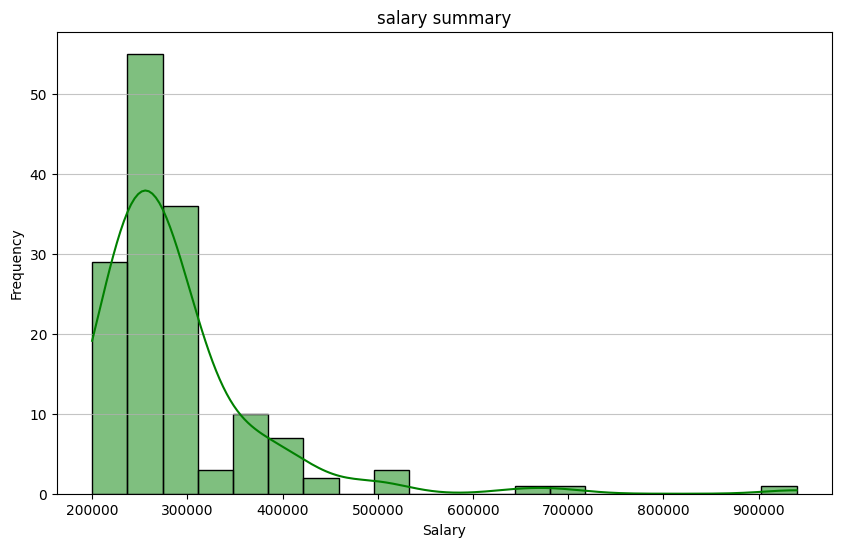

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['salary'].dropna(), bins=20, kde=True, color='green')
plt.title('salary summary')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

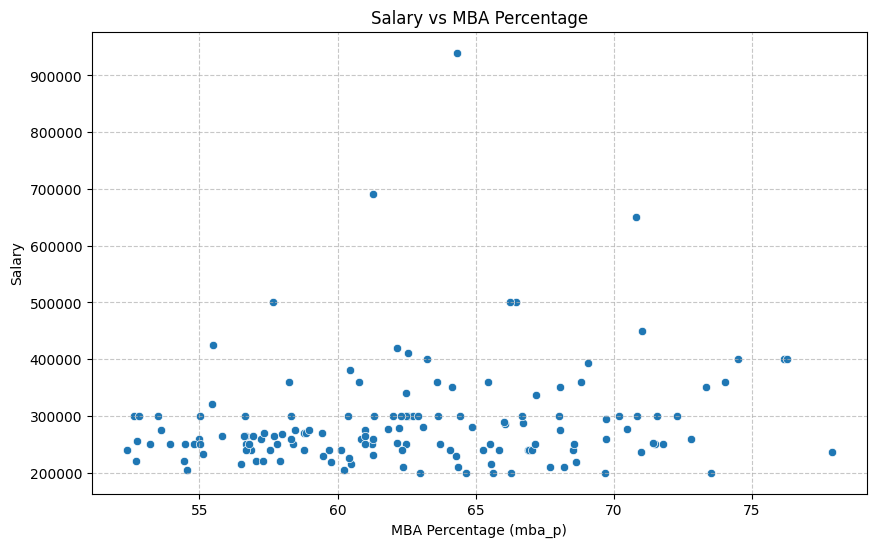

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='mba_p', y='salary', data=df.dropna(subset=['salary', 'mba_p']))
plt.title('Salary vs MBA Percentage')
plt.xlabel('MBA Percentage (mba_p)')
plt.ylabel('Salary')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

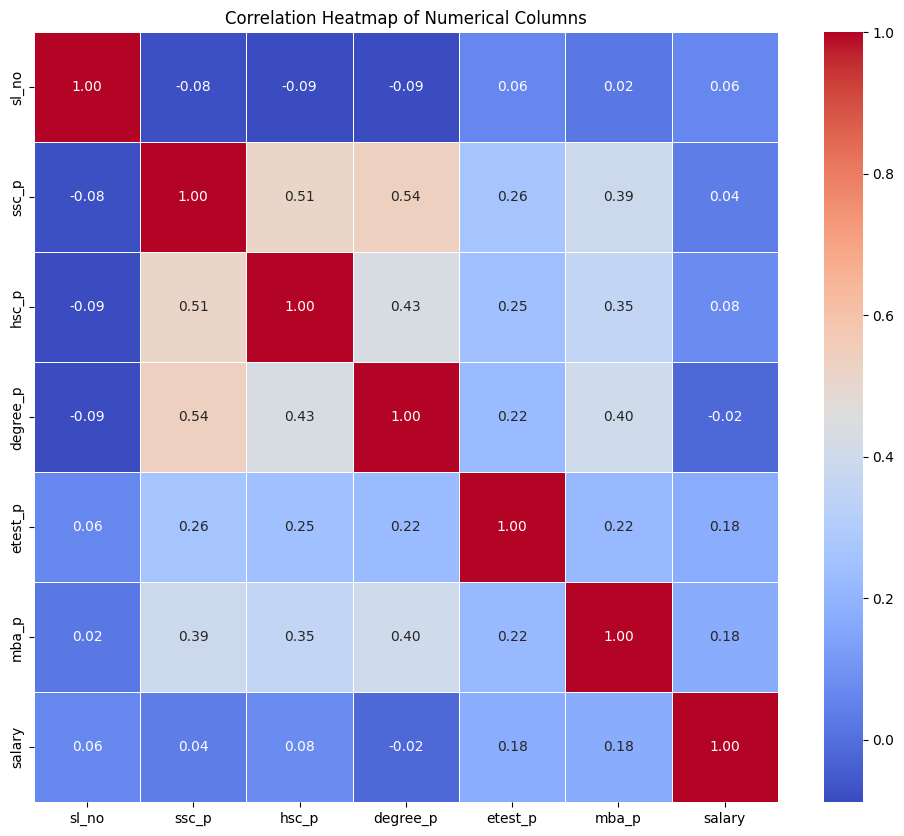

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation calculation
numerical_cols = df.select_dtypes(include=['number']).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

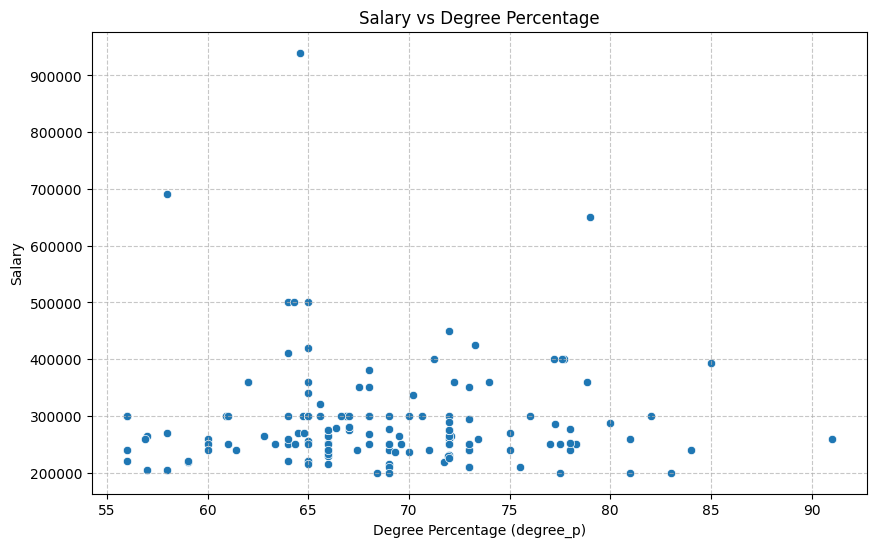

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='degree_p', y='salary', data=df.dropna(subset=['salary', 'degree_p']))
plt.title('Salary vs Degree Percentage')
plt.xlabel('Degree Percentage (degree_p)')
plt.ylabel('Salary')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### **Building a Random Forest Regression Model**

To build a regression model, we first need to prepare the data. This involves:
1.  Handling missing values.
2.  Encoding categorical features into a numerical format.
3.  Splitting the data into training and testing sets.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Make a copy of the DataFrame to avoid modifying the original 'df'
df_model = df.copy()

# Replace missing 'salary' values with the median of the 'salary' column
median_salary = df_model['salary'].median()
df_model['salary'] = df_model['salary'].fillna(median_salary)

# Identify categorical and numerical features
categorical_cols = df_model.select_dtypes(include=['object', 'category']).columns

# One-hot encode categorical variables
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# Drop 'sl_no' as it's just an identifier and not a feature
df_model = df_model.drop('sl_no', axis=1)

# Define features (X) and target (y)
X = df_model.drop('salary', axis=1)
y = df_model['salary']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (172, 15)
Shape of X_test: (43, 15)
Shape of y_train: (172,)
Shape of y_test: (43,)


### **Standardizing the Dataset**

Standardization (or Z-score normalization) is a common preprocessing step that transforms data to have a mean of 0 and a standard deviation of 1. While tree-based models like Random Forest are not typically sensitive to feature scaling, it is good practice, especially if you plan to experiment with other models (e.g., SVMs, neural networks, linear models) that are sensitive to the scale of features.

In [34]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Identify numerical columns for scaling (exclude dummy variables from one-hot encoding if any)
# For this dataset, all 'X' features are numerical or boolean (which StandardScaler handles fine)
# We'll select columns that are not boolean, to be more precise, although StandardScaler can handle False/True as 0/1
numerical_cols_to_scale = X_train.select_dtypes(include=['number']).columns

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train[numerical_cols_to_scale])
X_test_scaled = scaler.transform(X_test[numerical_cols_to_scale])

# Convert the scaled arrays back to DataFrames with original column names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=numerical_cols_to_scale, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=numerical_cols_to_scale, index=X_test.index)

# Reintegrate boolean/dummy variables that were not scaled (if any)
# In this specific case, all columns are numerical after one-hot encoding, so we might just replace directly
# If there were non-numeric columns that weren't meant to be scaled, you'd merge them back.
# For now, we assume all features in X are numerical after previous steps and we are scaling all of them.

X_train = X_train_scaled_df
X_test = X_test_scaled_df

print("Dataset standardized successfully.")
print(f"Shape of scaled X_train: {X_train.shape}")
print(f"Shape of scaled X_test: {X_test.shape}")

Dataset standardized successfully.
Shape of scaled X_train: (172, 5)
Shape of scaled X_test: (43, 5)


Now that the data is prepared, split, and standardized, let's train a Random Forest Regressor model again using the scaled data.

In [35]:
# Initialize and train the Random Forest Regressor with scaled data
# You can tune hyperparameters like n_estimators, max_depth, etc., for better performance
rf_regressor_scaled = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_regressor_scaled.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully with scaled data.")

Random Forest Regressor model trained successfully with scaled data.


Finally, let's make predictions on the scaled test set and calculate the R-squared value to evaluate the model's performance with standardized features.

In [36]:
# Make predictions on the scaled test set
y_pred_scaled = rf_regressor_scaled.predict(X_test)

# Calculate the R-squared value
r2_scaled = r2_score(y_test, y_pred_scaled)

print(f"R-squared value with scaled data: {r2_scaled:.4f}")

R-squared value with scaled data: -0.2606


### **Visualizing Actual vs. Predicted Salaries with Scaled Data**

Let's visualize the actual vs. predicted salaries after training the model with scaled features to see if there's any improvement or change in performance.

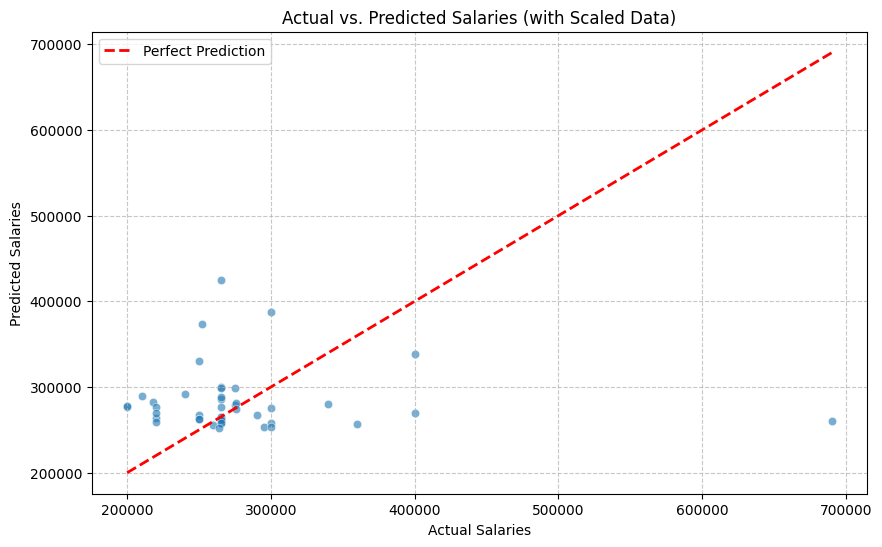

In [37]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_scaled, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Actual vs. Predicted Salaries (with Scaled Data)')
plt.xlabel('Actual Salaries')
plt.ylabel('Predicted Salaries')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

### **Training a Linear Regression Model**

Given the performance of the Random Forest Regressor, let's try a simpler, more interpretable model like Linear Regression. This model assumes a linear relationship between the features and the target variable. Since we've already standardized the data, it's suitable for Linear Regression.

In [42]:
from sklearn.linear_model import LinearRegression

# Initialize and train the Linear Regression model with scaled data
linear_regressor = LinearRegression()
linear_regressor.fit(X_train, y_train)

print("Linear Regression model trained successfully with scaled data.")

Linear Regression model trained successfully with scaled data.


Now, let's make predictions using the trained Linear Regression model and evaluate its performance with the R-squared metric.

In [43]:
# Make predictions on the scaled test set using Linear Regression
y_pred_linear = linear_regressor.predict(X_test)

# Calculate the R-squared value for Linear Regression
r2_linear = r2_score(y_test, y_pred_linear)

print(f"Linear Regression R-squared value with scaled data: {r2_linear:.4f}")

Linear Regression R-squared value with scaled data: -0.1244


### **Visualizing Actual vs. Predicted Salaries for Linear Regression**

Let's visualize the actual vs. predicted salaries for the Linear Regression model to assess its fit.

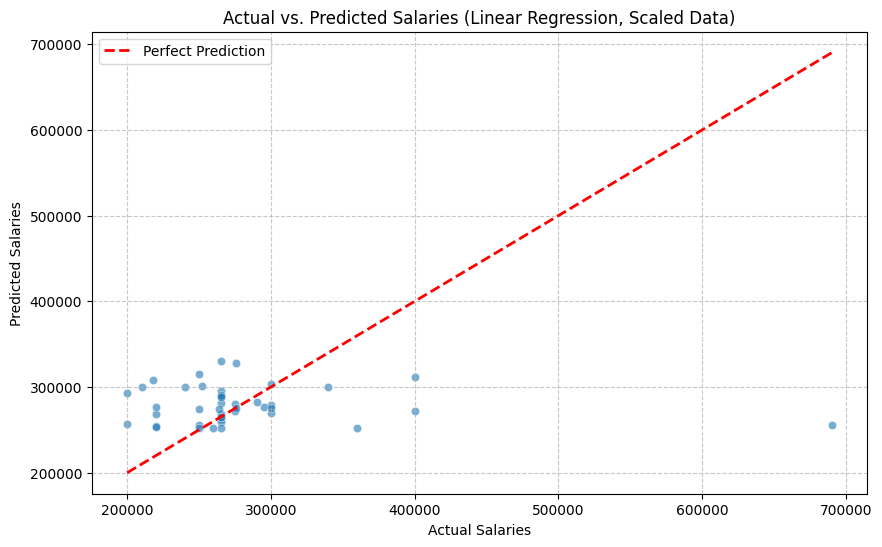

In [44]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_linear, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Actual vs. Predicted Salaries (Linear Regression, Scaled Data)')
plt.xlabel('Actual Salaries')
plt.ylabel('Predicted Salaries')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Now that the data is prepared and split, let's train a Random Forest Regressor model.

In [33]:
# Initialize and train the Random Forest Regressor
# You can tune hyperparameters like n_estimators, max_depth, etc., for better performance
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_regressor.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


Finally, let's make predictions on the test set and calculate the R-squared value to evaluate the model's performance.

In [ ]:
# Make predictions on the test set
y_pred = rf_regressor.predict(X_test)

# Calculate the R-squared value
r2 = r2_score(y_test, y_pred)

print(f"R-squared value: {r2:.4f}")

R-squared value: -0.3310


### **Visualizing Actual vs. Predicted Salaries**

Since the R-squared value is negative, let's visualize the actual vs. predicted salaries to understand where the model is performing poorly.

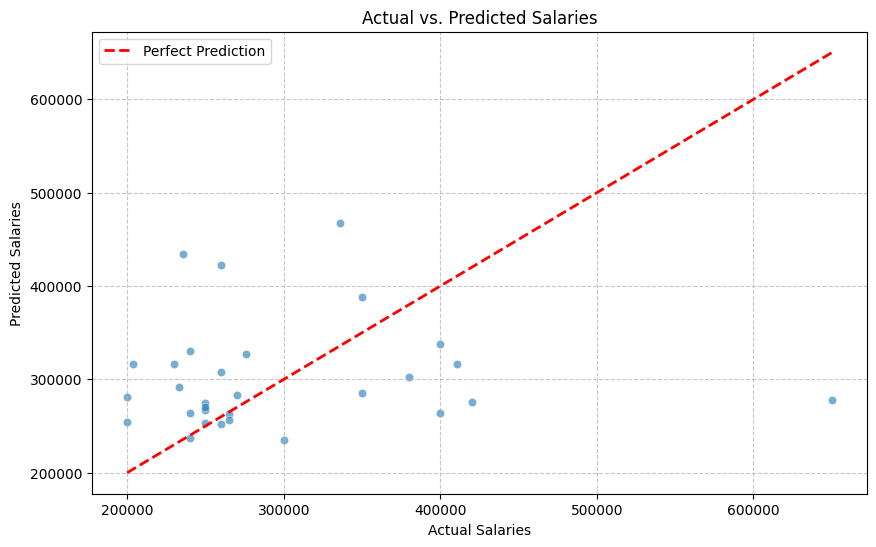

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Actual vs. Predicted Salaries')
plt.xlabel('Actual Salaries')
plt.ylabel('Predicted Salaries')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

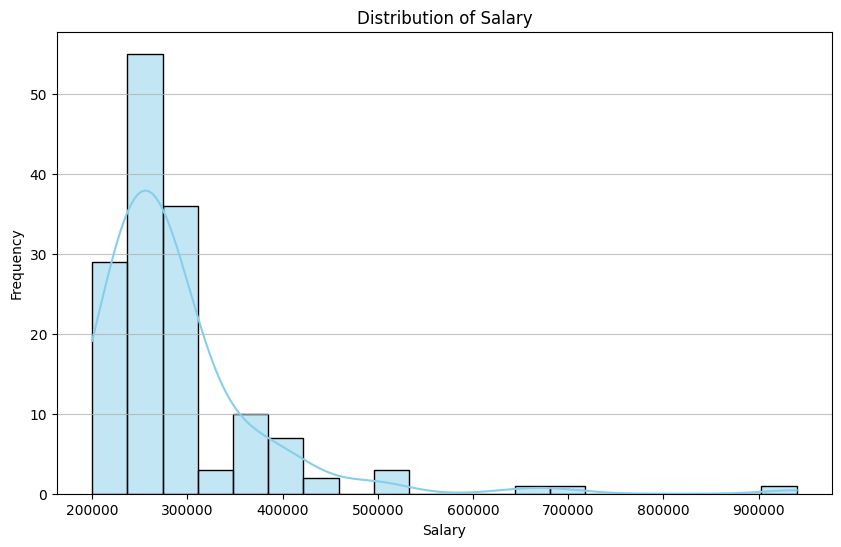

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['salary'].dropna(), bins=20, kde=True, color='skyblue')
plt.title('Distribution of Salary')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Make a copy of the DataFrame to avoid modifying the original 'df'
df_model = df.copy()

# Replace missing 'salary' values with the median of the 'salary' column
median_salary = df_model['salary'].median()
df_model['salary'] = df_model['salary'].fillna(median_salary)

# Identify categorical and numerical features
categorical_cols = df_model.select_dtypes(include=['object', 'category']).columns

# One-hot encode categorical variables
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# Drop 'sl_no' as it's just an identifier and not a feature
df_model = df_model.drop('sl_no', axis=1)

# Define features (X) and target (y)
X = df_model.drop('salary', axis=1)
y = df_model['salary']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (172, 15)
Shape of X_test: (43, 15)
Shape of y_train: (172,)
Shape of y_test: (43,)


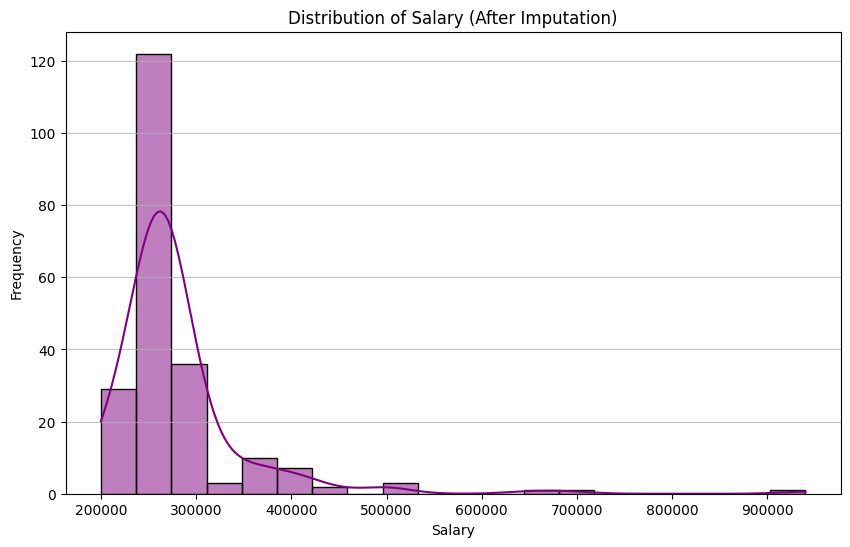

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_model['salary'], bins=20, kde=True, color='purple')
plt.title('Distribution of Salary (After Imputation)')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

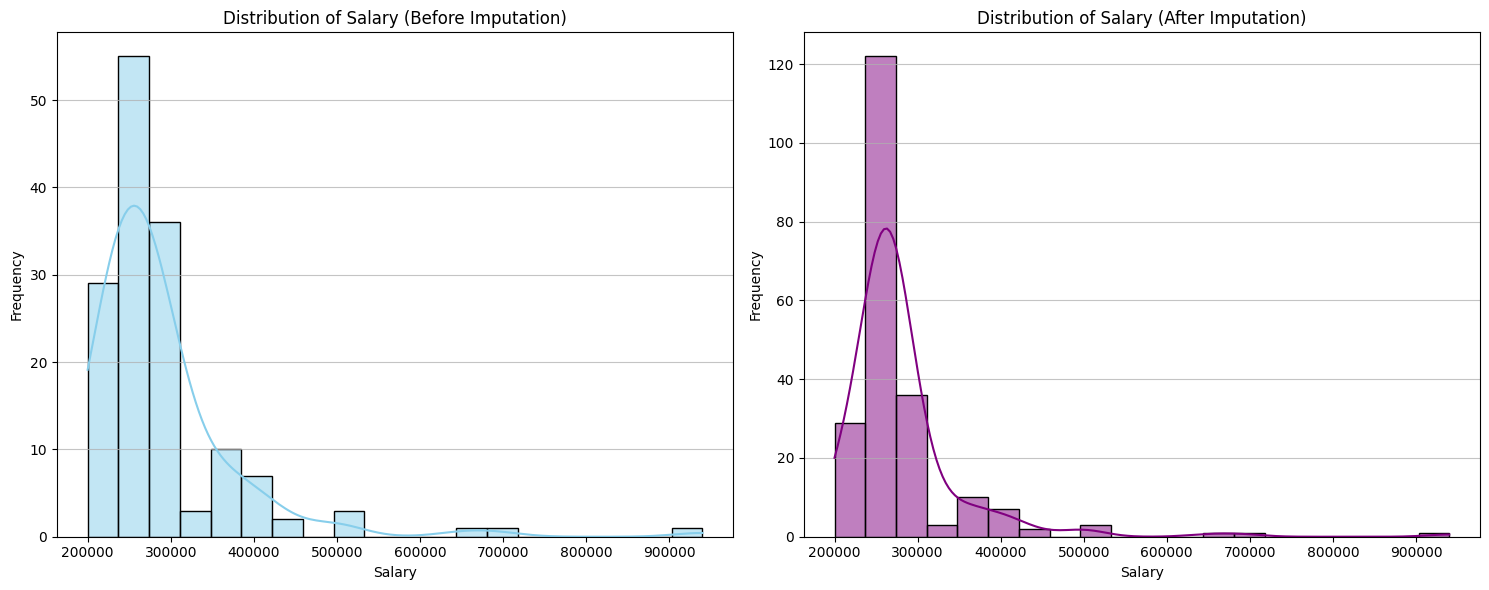

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

# Subplot 1: Distribution of Salary Before Imputation
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(df['salary'].dropna(), bins=20, kde=True, color='skyblue')
plt.title('Distribution of Salary (Before Imputation)')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# Subplot 2: Distribution of Salary After Imputation
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(df_model['salary'], bins=20, kde=True, color='purple')
plt.title('Distribution of Salary (After Imputation)')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

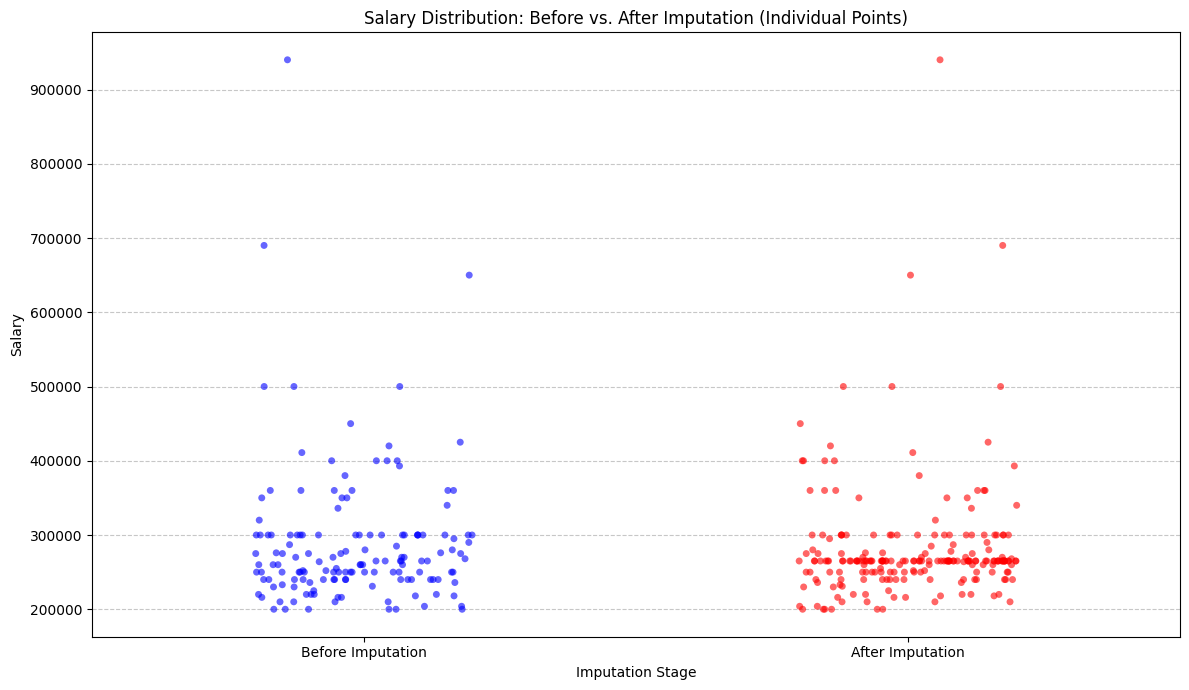

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for stripplot
# Create a Series for 'salary' before imputation (dropping NaNs)
temp_before = df['salary'].dropna().reset_index(drop=True).to_frame(name='salary')
temp_before['Imputation_Stage'] = 'Before Imputation'

# Create a Series for 'salary' after imputation
temp_after = df_model['salary'].reset_index(drop=True).to_frame(name='salary')
temp_after['Imputation_Stage'] = 'After Imputation'

# Concatenate the two Series into a single DataFrame for plotting
combined_df = pd.concat([temp_before, temp_after])

plt.figure(figsize=(12, 7))
sns.stripplot(x='Imputation_Stage', y='salary', hue='Imputation_Stage', data=combined_df, jitter=0.2, s=5, # s is marker size
              palette={'Before Imputation': 'blue', 'After Imputation': 'red'}, legend=False, alpha=0.6)
plt.title('Salary Distribution: Before vs. After Imputation (Individual Points)')
plt.xlabel('Imputation Stage')
plt.ylabel('Salary')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

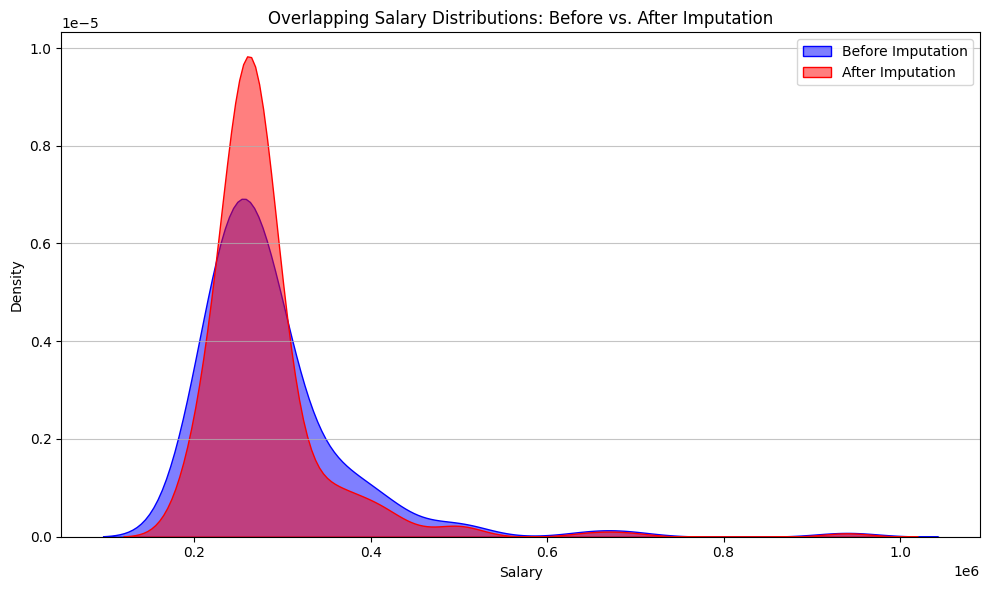

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Plot distribution of salary before imputation (dropping NaNs)
sns.kdeplot(df['salary'].dropna(), color='blue', fill=True, alpha=0.5, label='Before Imputation')

# Plot distribution of salary after imputation
sns.kdeplot(df_model['salary'], color='red', fill=True, alpha=0.5, label='After Imputation')

plt.title('Overlapping Salary Distributions: Before vs. After Imputation')
plt.xlabel('Salary')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

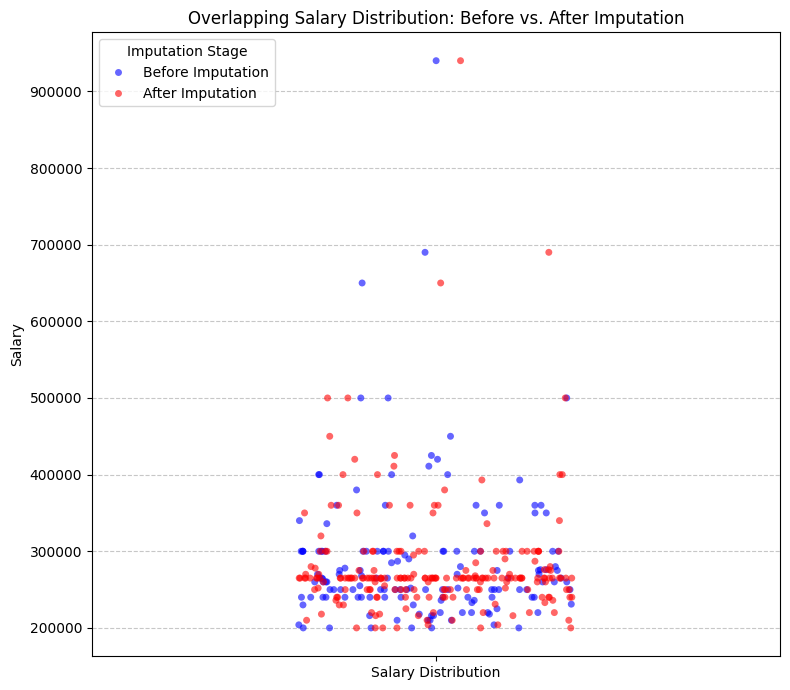

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for stripplot to overlap
# Create a Series for 'salary' before imputation (dropping NaNs)
temp_before = df['salary'].dropna().reset_index(drop=True).to_frame(name='salary')
temp_before['Imputation_Stage'] = 'Before Imputation'
temp_before['Category'] = 'Salary Distribution' # Common category for x-axis

# Create a Series for 'salary' after imputation
temp_after = df_model['salary'].reset_index(drop=True).to_frame(name='salary')
temp_after['Imputation_Stage'] = 'After Imputation'
temp_after['Category'] = 'Salary Distribution' # Common category for x-axis

# Concatenate the two Series into a single DataFrame for plotting
combined_df_overlap = pd.concat([temp_before, temp_after])

plt.figure(figsize=(8, 7))
sns.stripplot(x='Category', y='salary', hue='Imputation_Stage', data=combined_df_overlap, jitter=0.2, s=5, # s is marker size
              palette={'Before Imputation': 'blue', 'After Imputation': 'red'}, alpha=0.6)
plt.title('Overlapping Salary Distribution: Before vs. After Imputation')
plt.xlabel('') # Remove x-label as it's a single category
plt.ylabel('Salary')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Imputation Stage', loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats

# Extract salary data before and after imputation
salary_before_imputation = df['salary'].dropna()
salary_after_imputation = df_model['salary']

# Perform independent two-sample t-test
t_statistic, p_value = stats.ttest_ind(salary_before_imputation, salary_after_imputation, equal_var=False) # Use Welch's t-test for unequal variances

print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret the results
alpha = 0.05 # Significance level
if p_value < alpha:
    print(f"Since the p-value ({p_value:.4f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("Conclusion: There is a statistically significant difference in the salary distribution after imputation.")
else:
    print(f"Since the p-value ({p_value:.4f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("Conclusion: There is no statistically significant difference in the salary distribution after imputation.")

T-statistic: 0.7881
P-value: 0.4313
Since the p-value (0.4313) is greater than the significance level (0.05), we fail to reject the null hypothesis.
Conclusion: There is no statistically significant difference in the salary distribution after imputation.


### **Standard Deviation of the Dataset**

Let's examine the standard deviation of the `df` DataFrame, the 'salary' column, and then `X_train` and `X_test` after standardization to observe the impact of scaling.

In [38]:
# Standard deviation of the original DataFrame (only numerical columns)
print("Standard deviation of the original numerical features in df:")
display(df.select_dtypes(include=['number']).std())

# Standard deviation of the 'salary' column (original)
print(f"\nStandard deviation of 'salary' in original df: {df['salary'].std():.2f}")

# Standard deviation of X_train and X_test after standardization
print("\nStandard deviation of X_train after standardization:")
display(X_train.std())

print("\nStandard deviation of X_test after standardization:")
display(X_test.std())

Standard deviation of the original numerical features in df:


,0
sl_no,62.209324
ssc_p,10.827205
hsc_p,10.897509
degree_p,7.358743
etest_p,13.275956
mba_p,5.833385
salary,93457.452420



Standard deviation of 'salary' in original df: 93457.45

Standard deviation of X_train after standardization:


,0
ssc_p,1.00292
hsc_p,1.00292
degree_p,1.00292
etest_p,1.00292
mba_p,1.00292



Standard deviation of X_test after standardization:


,0
ssc_p,0.982923
hsc_p,0.709235
degree_p,0.848266
etest_p,0.957950
mba_p,0.922498


### **Training an XGBoost Regressor Model**

Given the results from Random Forest and Linear Regression, let's try an ensemble boosting model like XGBoost Regressor. XGBoost is often very effective for structured data and can capture complex non-linear relationships.

In [48]:
import xgboost as xgb

# Initialize and train the XGBoost Regressor model with scaled data
# You can tune hyperparameters for better performance
xgb_regressor = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42, n_jobs=-1)
xgb_regressor.fit(X_train, y_train)

print("XGBoost Regressor model trained successfully with scaled data.")

XGBoost Regressor model trained successfully with scaled data.


Now, let's make predictions using the trained XGBoost Regressor model and evaluate its performance with the R-squared metric.

In [49]:
# Make predictions on the scaled test set using XGBoost Regressor
y_pred_xgb = xgb_regressor.predict(X_test)

# Calculate the R-squared value for XGBoost Regressor
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Regressor R-squared value with scaled data: {r2_xgb:.4f}")

XGBoost Regressor R-squared value with scaled data: -0.5375


### **Visualizing Actual vs. Predicted Salaries for XGBoost Regressor**

Let's visualize the actual vs. predicted salaries for the XGBoost Regressor model to assess its fit.

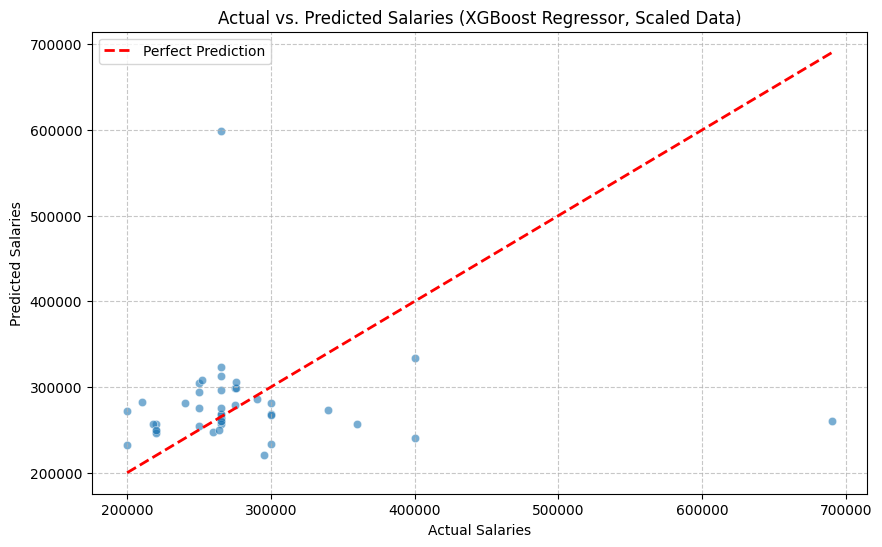

In [50]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Actual vs. Predicted Salaries (XGBoost Regressor, Scaled Data)')
plt.xlabel('Actual Salaries')
plt.ylabel('Predicted Salaries')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

### **Exploring Feature Engineering: Polynomial Features**

Given the consistently low R-squared values, it's possible that the relationship between our features and the target variable (salary) is not purely linear, and might involve interactions or higher-order terms. One way to capture these non-linearities is by creating **polynomial features**.

We will use `PolynomialFeatures` from `sklearn.preprocessing` to generate new features that are polynomial combinations of the existing numerical features. This includes terms like $X^2$, $Y^2$, and $XY$ (for degree 2).

**Note:** We will apply this to the original `X` DataFrame (before scaling) to ensure that the polynomial features are generated from the raw values, and then we will re-split and re-scale the data.

In [52]:
from sklearn.preprocessing import PolynomialFeatures

# Re-create X and y from df_model before any splitting or scaling for consistent feature engineering
# This ensures we are working with the full dataset for feature generation
df_model_fe = df.copy()
median_salary_fe = df_model_fe['salary'].median()
df_model_fe['salary'] = df_model_fe['salary'].fillna(median_salary_fe)
categorical_cols_fe = df_model_fe.select_dtypes(include=['object', 'category']).columns
df_model_fe = pd.get_dummies(df_model_fe, columns=categorical_cols_fe, drop_first=True)
df_model_fe = df_model_fe.drop('sl_no', axis=1)
X_fe = df_model_fe.drop('salary', axis=1)
y_fe = df_model_fe['salary']

# Select only the original numerical columns from X_fe to generate polynomial features
# This avoids creating polynomial features from one-hot encoded categorical columns unnecessarily
original_numerical_cols = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']
X_numerical_for_poly = X_fe[original_numerical_cols]

# Initialize PolynomialFeatures with a degree (e.g., 2) and include bias
poly = PolynomialFeatures(degree=2, include_bias=False) # include_bias=False to avoid adding a column of all ones

# Fit and transform the numerical features to create polynomial features
X_poly_features = poly.fit_transform(X_numerical_for_poly)

# Create a DataFrame for the new polynomial features
poly_feature_names = poly.get_feature_names_out(X_numerical_for_poly.columns)
X_poly_df = pd.DataFrame(X_poly_features, columns=poly_feature_names, index=X_fe.index)

# Drop the original numerical columns and concatenate the new polynomial features
# This replaces the original numerical columns with their polynomial versions
X_fe_processed = X_fe.drop(columns=original_numerical_cols)
X_transformed = pd.concat([X_fe_processed, X_poly_df], axis=1)

print(f"Original number of features: {X_fe.shape[1]}")
print(f"Number of features after adding polynomial terms: {X_transformed.shape[1]}")
display(X_transformed.head())

Original number of features: 15
Number of features after adding polynomial terms: 30


,gender_M,ssc_b_Others,hsc_b_Others,hsc_s_Commerce,hsc_s_Science,degree_t_Others,degree_t_Sci&Tech,workex_Yes,specialisation_Mkt&HR,status_Placed,...,hsc_p^2,hsc_p degree_p,hsc_p etest_p,hsc_p mba_p,degree_p^2,degree_p etest_p,degree_p mba_p,etest_p^2,etest_p mba_p,mba_p^2
0,True,True,True,True,False,False,True,False,True,True,...,8281.0000,5278.0000,5005.000,5350.8000,3364.0000,3190.00,3410.4000,3025.00,3234.00,3457.4400
1,True,False,True,False,True,False,True,True,False,True,...,6135.5889,6069.0084,6775.545,5191.7124,6003.1504,6702.02,5135.3744,7482.25,5733.22,4393.0384
2,True,False,False,False,False,False,False,False,False,True,...,4624.0000,4352.0000,5100.000,3930.4000,4096.0000,4800.00,3699.2000,5625.00,4335.00,3340.8400
3,True,False,False,False,True,False,True,False,True,False,...,2704.0000,2704.0000,3432.000,3090.3600,2704.0000,3432.00,3090.3600,4356.00,3922.38,3531.9249
4,True,False,False,True,False,False,False,False,False,True,...,5416.9600,5394.8800,7124.480,4084.8000,5372.8900,7095.44,4068.1500,9370.24,5372.40,3080.2500


Now that we have new polynomial features, we need to re-split the data into training and testing sets, and then re-apply `StandardScaler` to these new features. After scaling, we can re-train and evaluate the models to see if the polynomial features improve performance.

### **Re-splitting and Re-scaling Data with Polynomial Features**

Now that we have created polynomial features, we need to re-split the `X_transformed` and `y_fe` into training and testing sets. Then, we will apply `StandardScaler` to these new sets, as the scale of these new features might be very different and standardization is crucial for many models, especially those sensitive to feature scales like Linear Regression.

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Re-split the data with the new polynomial features
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_transformed, y_fe, test_size=0.2, random_state=42)

# Initialize and apply StandardScaler to the new training and testing sets
scaler_poly = StandardScaler()
X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)
X_test_poly_scaled = scaler_poly.transform(X_test_poly)

# Convert scaled arrays back to DataFrames for consistency and easier inspection
X_train_poly_scaled_df = pd.DataFrame(X_train_poly_scaled, columns=X_train_poly.columns, index=X_train_poly.index)
X_test_poly_scaled_df = pd.DataFrame(X_test_poly_scaled, columns=X_test_poly.columns, index=X_test_poly.index)

print("Data re-split and re-scaled successfully with polynomial features.")
print(f"Shape of X_train_poly_scaled_df: {X_train_poly_scaled_df.shape}")
print(f"Shape of X_test_poly_scaled_df: {X_test_poly_scaled_df.shape}")

Data re-split and re-scaled successfully with polynomial features.
Shape of X_train_poly_scaled_df: (172, 30)
Shape of X_test_poly_scaled_df: (43, 30)


### **Retraining Linear Regression with Polynomial Features**

Let's retrain the Linear Regression model using the newly created and scaled polynomial features to see if this feature engineering technique improves the model's performance.

In [59]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Initialize and train the Linear Regression model with scaled polynomial features
linear_regressor_poly = LinearRegression()
linear_regressor_poly.fit(X_train_poly_scaled_df, y_train_poly)

print("Linear Regression model trained successfully with scaled polynomial features.")

Linear Regression model trained successfully with scaled polynomial features.


Now, let's make predictions using the trained Linear Regression model with polynomial features and evaluate its performance with the R-squared metric.

In [60]:
# Make predictions on the scaled test set using Linear Regression with polynomial features
y_pred_linear_poly = linear_regressor_poly.predict(X_test_poly_scaled_df)

# Calculate the R-squared value for Linear Regression with polynomial features
r2_linear_poly = r2_score(y_test_poly, y_pred_linear_poly)

print(f"Linear Regression R-squared value with scaled polynomial features: {r2_linear_poly:.4f}")

Linear Regression R-squared value with scaled polynomial features: -0.1408


### **Visualizing Actual vs. Predicted Salaries for Linear Regression with Polynomial Features**

Let's visualize the actual vs. predicted salaries for the Linear Regression model with polynomial features to assess its fit.

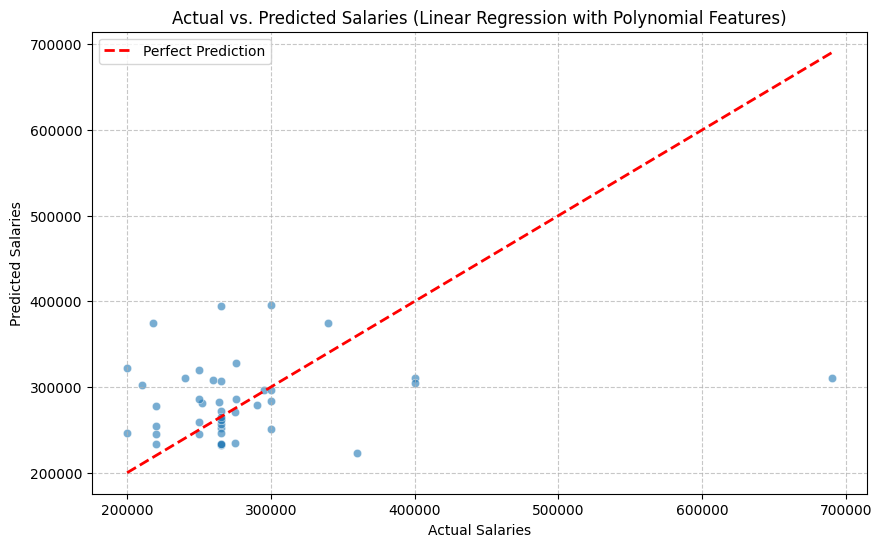

In [61]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_poly, y=y_pred_linear_poly, alpha=0.6)
plt.plot([y_test_poly.min(), y_test_poly.max()], [y_test_poly.min(), y_test_poly.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Actual vs. Predicted Salaries (Linear Regression with Polynomial Features)')
plt.xlabel('Actual Salaries')
plt.ylabel('Predicted Salaries')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

### **Graphical Comparison of Model Performance (R-squared Values)**

Let's visualize the R-squared values of all the models trained to compare their performance side-by-side. This will help in understanding which approach, including feature engineering, has yielded the best results.

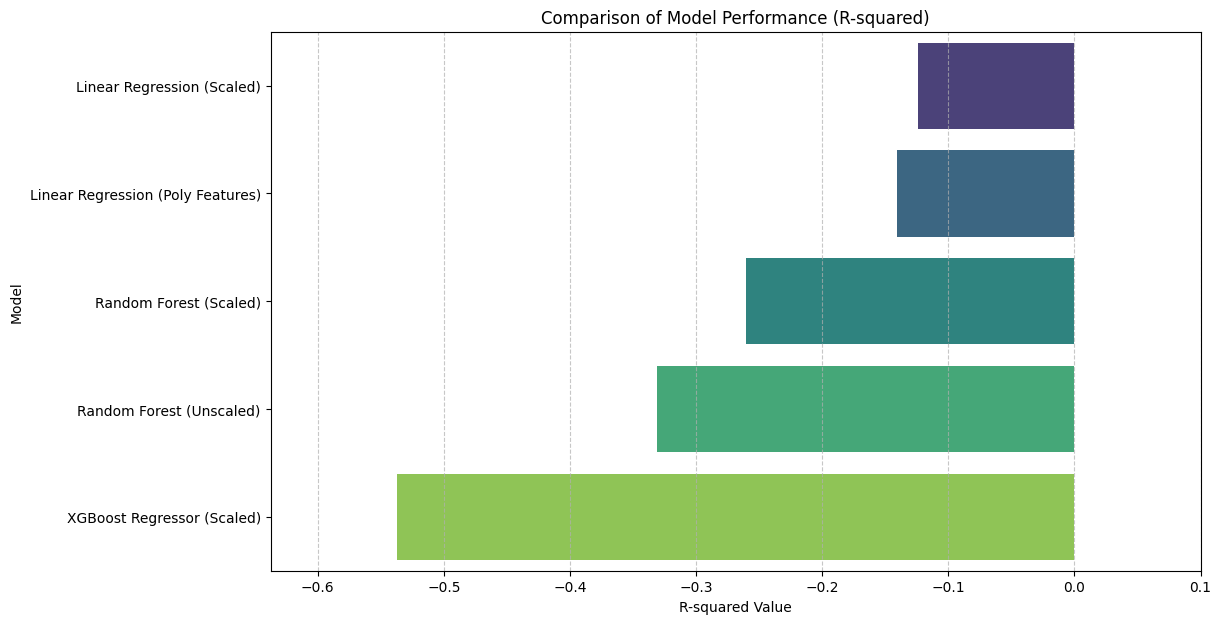

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Collect all R-squared values
model_names = [
    'Random Forest (Unscaled)',
    'Random Forest (Scaled)',
    'Linear Regression (Scaled)',
    'XGBoost Regressor (Scaled)',
    'Linear Regression (Poly Features)'
]

r2_values = [
    r2,              # from Random Forest (Unscaled)
    r2_scaled,       # from Random Forest (Scaled)
    r2_linear,       # from Linear Regression (Scaled)
    r2_xgb,          # from XGBoost Regressor (Scaled)
    r2_linear_poly   # from Linear Regression (Polynomial Features)
]

# Create a DataFrame for easy plotting
r2_df = pd.DataFrame({
    'Model': model_names,
    'R-squared': r2_values
})

# Sort by R-squared value for better visualization
r2_df = r2_df.sort_values(by='R-squared', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='R-squared', y='Model', hue='Model', data=r2_df, palette='viridis', legend=False) # Add hue and legend=False to resolve FutureWarning
plt.title('Comparison of Model Performance (R-squared)')
plt.xlabel('R-squared Value')
plt.ylabel('Model')
plt.xlim(min(r2_values) - 0.1, max(0, max(r2_values)) + 0.1) # Adjust x-axis limits
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()